<a href="https://colab.research.google.com/github/Swaminathan005/EDA-Project/blob/Review-1/R1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Importing the packages

In [2]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

##Dowloading the Dataset: **AI Impact on Jobs 2030**

In [5]:
from kagglehub import KaggleDatasetAdapter, dataset_load

m_data = dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "khushikyad001/ai-impact-on-jobs-2030",
    "AI_Impact_on_Jobs_2030.csv" # Updated filename based on directory listing
)

100%|██████████| 296k/296k [00:00<00:00, 55.9MB/s]


##Understanding the dataset

In [6]:
print(m_data.head())

             Job_Title  Average_Salary  Years_Experience Education_Level  \
0       Security Guard           45795                28        Master's   
1   Research Scientist          133355                20             PhD   
2  Construction Worker          146216                 2     High School   
3    Software Engineer          136530                13             PhD   
4    Financial Analyst           70397                22     High School   

   AI_Exposure_Index  Tech_Growth_Factor  Automation_Probability_2030  \
0               0.18                1.28                         0.85   
1               0.62                1.11                         0.05   
2               0.86                1.18                         0.81   
3               0.39                0.68                         0.60   
4               0.52                1.46                         0.64   

  Risk_Category  Skill_1  Skill_2  Skill_3  Skill_4  Skill_5  Skill_6  \
0          High     0.45     0.

In [7]:
print(m_data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Job_Title                    3000 non-null   object 
 1   Average_Salary               3000 non-null   int64  
 2   Years_Experience             3000 non-null   int64  
 3   Education_Level              3000 non-null   object 
 4   AI_Exposure_Index            3000 non-null   float64
 5   Tech_Growth_Factor           3000 non-null   float64
 6   Automation_Probability_2030  3000 non-null   float64
 7   Risk_Category                3000 non-null   object 
 8   Skill_1                      3000 non-null   float64
 9   Skill_2                      3000 non-null   float64
 10  Skill_3                      3000 non-null   float64
 11  Skill_4                      3000 non-null   float64
 12  Skill_5                      3000 non-null   float64
 13  Skill_6           

In [8]:
m_data.describe()

,Average_Salary,Years_Experience,AI_Exposure_Index,Tech_Growth_Factor,Automation_Probability_2030,Skill_1,Skill_2,Skill_3,Skill_4,Skill_5,Skill_6,Skill_7,Skill_8,Skill_9,Skill_10
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,89372.279000,14.677667,0.501283,0.995343,0.501503,0.496973,0.497233,0.499313,0.503667,0.490270,0.499807,0.499160,0.502843,0.501433,0.493627
std,34608.088767,8.739788,0.284004,0.287669,0.247881,0.287888,0.288085,0.288354,0.287063,0.285818,0.286050,0.288044,0.289832,0.285818,0.286464
min,30030.000000,0.000000,0.000000,0.500000,0.050000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,58640.000000,7.000000,0.260000,0.740000,0.310000,0.240000,0.250000,0.250000,0.260000,0.240000,0.260000,0.250000,0.250000,0.260000,0.250000
50%,89318.000000,15.000000,0.500000,1.000000,0.500000,0.505000,0.500000,0.500000,0.510000,0.490000,0.500000,0.490000,0.500000,0.500000,0.490000
75%,119086.500000,22.000000,0.740000,1.240000,0.700000,0.740000,0.740000,0.750000,0.750000,0.730000,0.740000,0.750000,0.750000,0.740000,0.740000
max,149798.000000,29.000000,1.000000,1.500000,0.950000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [28]:
m_data["Education_Level"].value_counts()
m_data["Risk_Category"].value_counts()

,count
Risk_Category,
Medium,1521
High,740
Low,739


using Box plots to detect
outliers

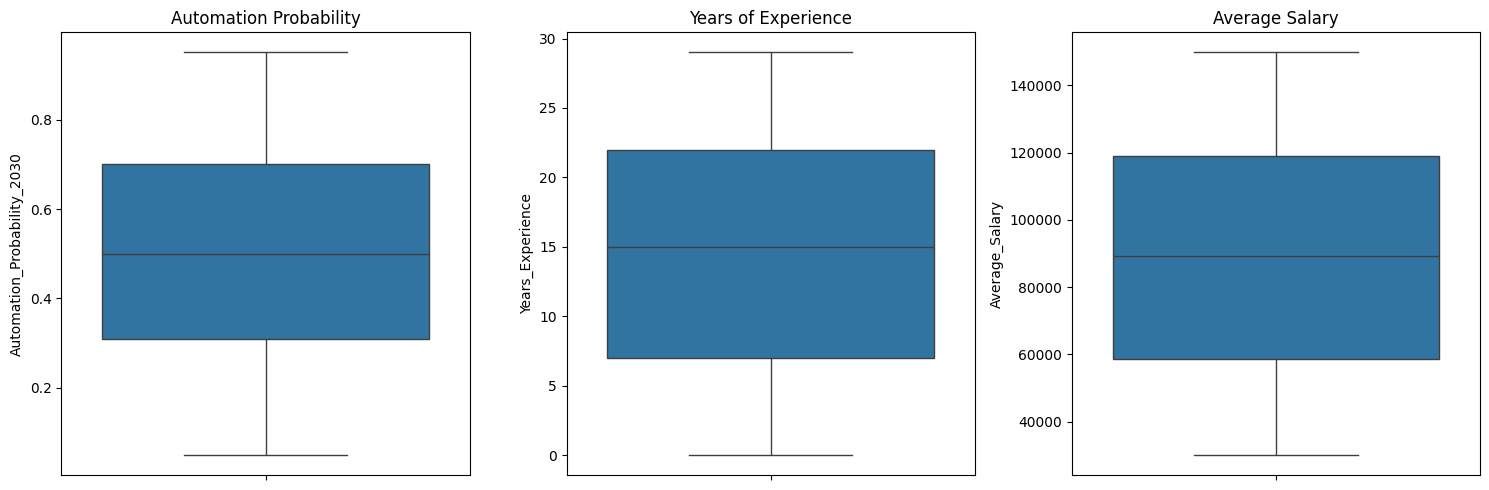

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.boxplot(y=m_data['Automation_Probability_2030'], ax=axes[0])
axes[0].set_title('Automation Probability')

sns.boxplot(y=m_data['Years_Experience'], ax=axes[1])
axes[1].set_title('Years of Experience')

sns.boxplot(y=m_data['Average_Salary'], ax=axes[2])
axes[2].set_title('Average Salary')

plt.tight_layout()
plt.show()


checking whether the categorical data are encoded or not

In [18]:
categorical_cols = m_data.select_dtypes(include='object').columns
categorical_cols

Index(['Job_Title', 'Education_Level', 'Risk_Category'], dtype='object')

In [19]:
for col in categorical_cols:
    print(f"\n{col} unique values:")
    print(m_data[col].unique())


Job_Title unique values:
['Security Guard' 'Research Scientist' 'Construction Worker'
 'Software Engineer' 'Financial Analyst' 'AI Engineer' 'Mechanic'
 'Teacher' 'HR Specialist' 'Customer Support' 'UX Researcher' 'Lawyer'
 'Data Scientist' 'Graphic Designer' 'Retail Worker' 'Doctor'
 'Truck Driver' 'Chef' 'Nurse' 'Marketing Manager']

Education_Level unique values:
["Master's" 'PhD' 'High School' "Bachelor's"]

Risk_Category unique values:
['High' 'Low' 'Medium']


checking the skewness for scaling


In [33]:
m_data[['Average_Salary', 'Years_Experience', 'Tech_Growth_Factor']].skew()


,0
Average_Salary,0.011552
Years_Experience,-0.008568
Tech_Growth_Factor,-0.013538


Checking the relation between features

In [24]:
corr = m_data.corr(numeric_only=True)
corr['Automation_Probability_2030'].sort_values(ascending = False)

,Automation_Probability_2030
Automation_Probability_2030,1.000000
Skill_1,0.030947
Tech_Growth_Factor,0.025538
Skill_2,0.024247
AI_Exposure_Index,0.014320
Skill_6,0.011701
Skill_4,0.005963
Skill_10,0.002665
Skill_9,0.001269
Skill_7,-0.010226


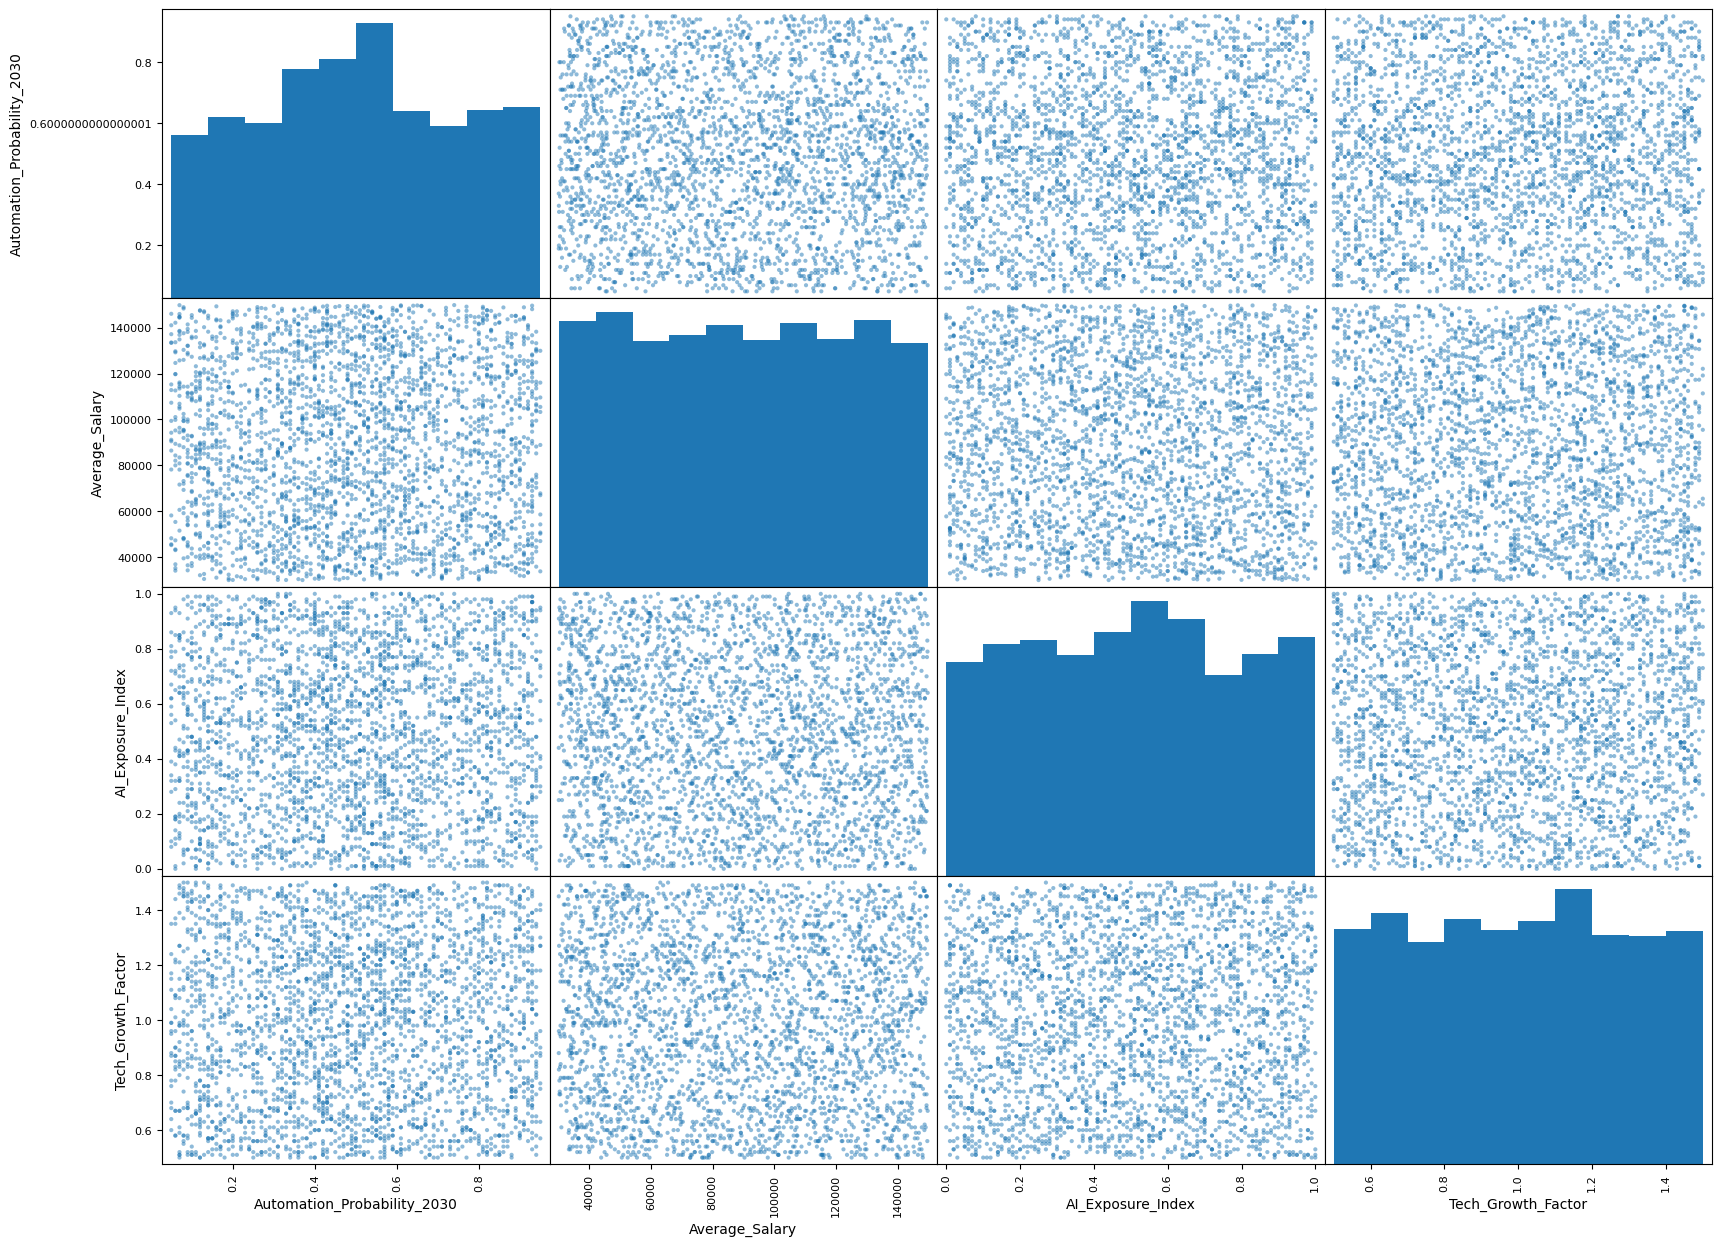

In [26]:
attributes = ["Automation_Probability_2030","Average_Salary","AI_Exposure_Index","Tech_Growth_Factor"]
pd.plotting.scatter_matrix(m_data[attributes], figsize=(20,15))
plt.show()

In [37]:
m_data[[f'Skill_{i}' for i in range(1,11)]].corrwith(
    m_data  ['Automation_Probability_2030']
).sort_values()

,0
Skill_5,-0.026349
Skill_3,-0.020198
Skill_8,-0.016452
Skill_7,-0.010226
Skill_9,0.001269
Skill_10,0.002665
Skill_4,0.005963
Skill_6,0.011701
Skill_2,0.024247
Skill_1,0.030947


##Preprocessing

Encoding Education_Level

In [31]:
from sklearn.preprocessing import OrdinalEncoder
education_order = [['High School', 'Bachelor', 'Master', 'PhD']]

encoder = OrdinalEncoder(categories=education_order,handle_unknown='use_encoded_value',unknown_value=-1)

m_data[['Education_Level_Encoded']] = encoder.fit_transform(m_data[['Education_Level']])

removing Risk_Category from the dataset

In [32]:
m_data = m_data.drop(columns='Risk_Category')

scaling the Average_Salary to range [0,1]

In [34]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

features_to_scale = ['Average_Salary','Years_Experience','Tech_Growth_Factor']

m_data[features_to_scale] = scaler.fit_transform(m_data[features_to_scale])


feature Engineering

In [38]:
m_data['Avg_Skill'] = m_data[[f'Skill_{i}' for i in range(1,11)]].mean(axis=1)
m_data['Skill_STD'] = m_data[[f'Skill_{i}' for i in range(1,11)]].std(axis=1)
m_data['High_Skill_Count'] = (m_data[[f'Skill_{i}' for i in range(1,11)]] > 0.7).sum(axis=1)

In [39]:
corr = m_data.corr(numeric_only=True)
corr['Automation_Probability_2030'].sort_values(ascending = False)

,Automation_Probability_2030
Automation_Probability_2030,1.000000
Skill_1,0.030947
Tech_Growth_Factor,0.025538
Skill_2,0.024247
AI_Exposure_Index,0.014320
Skill_6,0.011701
Skill_4,0.005963
Skill_10,0.002665
Education_Level_Encoded,0.002515
Skill_9,0.001269


##Final Changes

In [40]:
m_data.describe()

,Average_Salary,Years_Experience,AI_Exposure_Index,Tech_Growth_Factor,Automation_Probability_2030,Skill_1,Skill_2,Skill_3,Skill_4,Skill_5,Skill_6,Skill_7,Skill_8,Skill_9,Skill_10,Education_Level_Encoded,Avg_Skill,Skill_STD,High_Skill_Count
count,3.000000e+03,3.000000e+03,3000.000000,3.000000e+03,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,1.503982e-16,-3.789561e-17,0.501283,-9.000208e-17,0.501503,0.496973,0.497233,0.499313,0.503667,0.490270,0.499807,0.499160,0.502843,0.501433,0.493627,0.216000,0.498433,0.283615,2.893333
std,1.000167e+00,1.000167e+00,0.284004,1.000167e+00,0.247881,0.287888,0.288085,0.288354,0.287063,0.285818,0.286050,0.288044,0.289832,0.285818,0.286464,1.613137,0.090470,0.046896,1.426640
min,-1.714980e+00,-1.679688e+00,0.000000,-1.722211e+00,0.050000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.000000,0.222000,0.097005,0.000000
25%,-8.881566e-01,-8.786193e-01,0.260000,-8.877783e-01,0.310000,0.240000,0.250000,0.250000,0.260000,0.240000,0.260000,0.250000,0.250000,0.260000,0.250000,-1.000000,0.438000,0.253500,2.000000
50%,-1.568652e-03,3.688729e-02,0.500000,1.619031e-02,0.500000,0.505000,0.500000,0.500000,0.510000,0.490000,0.500000,0.490000,0.500000,0.500000,0.490000,-0.500000,0.500000,0.284630,3.000000
75%,8.587349e-01,8.379556e-01,0.740000,8.506229e-01,0.700000,0.740000,0.740000,0.750000,0.750000,0.730000,0.740000,0.750000,0.750000,0.740000,0.740000,0.000000,0.556000,0.316453,4.000000
max,1.746291e+00,1.639024e+00,1.000000,1.754591e+00,0.950000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.000000,0.796000,0.434466,9.000000


In [41]:
m_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 21 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Job_Title                    3000 non-null   object 
 1   Average_Salary               3000 non-null   float64
 2   Years_Experience             3000 non-null   float64
 3   Education_Level              3000 non-null   object 
 4   AI_Exposure_Index            3000 non-null   float64
 5   Tech_Growth_Factor           3000 non-null   float64
 6   Automation_Probability_2030  3000 non-null   float64
 7   Skill_1                      3000 non-null   float64
 8   Skill_2                      3000 non-null   float64
 9   Skill_3                      3000 non-null   float64
 10  Skill_4                      3000 non-null   float64
 11  Skill_5                      3000 non-null   float64
 12  Skill_6                      3000 non-null   float64
 13  Skill_7           